# camel beauty assessor — frozen backbone sweep

every run here freezes part of the network instead of fine-tuning all of it. three freeze depths
across six datasets, plus one control that turns mosaic back on.

| axis | values |
|---|---|
| freeze depth | `11` backbone, `16` backbone and half the neck, `23` head only |
| augmentation | none, 90 degree turns, 45 degree turns |
| colour | rgb, grayscale |

mosaic is off, matching `fine-tuning_experiments.ipynb`, so these compare directly to `e0-nomosaic` and the rest.
`c-mosaic` is the single run that puts it back.

## 1. setup

### 1.1 imports

In [1]:
import os
import csv
import time
import pathlib
import collections

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import mlflow
from ultralytics import YOLO, settings as yolo_settings

print(f"torch {torch.__version__}   cuda {torch.cuda.is_available()}")

torch 2.14.0+cu130   cuda True


### 1.2 paths

In [2]:
root = pathlib.Path.cwd()
project = root / "runs" / "baseline"
results = root / "results"
weights_dir = root / "weights"

datasets = {
    "plain": root / "dataset" / "camel-det-plain",
    "plain-gray": root / "dataset" / "camel-det-gray",
    "rot90": root / "dataset" / "camel-det-aug",
    "rot90-gray": root / "dataset" / "camel-det-aug-gray",
    "rot45": root / "dataset" / "camel-det-rot45",
    "rot45-gray": root / "dataset" / "camel-det-rot45-gray",
}

### 1.3 display options

In [3]:
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})

pd.set_option("display.width", 250)
pd.set_option("display.max_columns", 60)
pd.set_option("display.max_rows", 300)
pd.set_option("display.max_colwidth", 115)
pd.set_option("display.expand_frame_repr", False)

### 1.4 config

In [4]:
seed = 42
splits = ["train", "val", "test"]
freezes = [11, 16, 23]

canon = ["Camel", "High_withers", "Large-head", "Large-lips", "Large-nose",
         "Large_hump", "Long-legs", "Long-neck", "Wide_body"]

epochs = 200
imgsz = 640
patience = 50
mosaic = 0.0

### 1.5 device

In [5]:
device = 0 if torch.cuda.is_available() else "cpu"
batch = 16 if device != "cpu" else 8
workers = 8 if device != "cpu" else 2
amp = device != "cpu"

print(f"device {device}   batch {batch}   workers {workers}   amp {amp}")
print(f"cuda: {torch.cuda.get_device_name(0)}")

device 0   batch 16   workers 8   amp True
cuda: NVIDIA GeForce RTX 4080 SUPER


### 1.6 experiment tracking

In [6]:
tracking_uri = "sqlite:///" + (root / "mlflow.db").resolve().as_posix()
os.environ["MLFLOW_TRACKING_URI"] = tracking_uri
os.environ["MLFLOW_EXPERIMENT_NAME"] = "camel-beauty-cv"
yolo_settings.update({"mlflow": True})

mlflow.set_tracking_uri(tracking_uri)
mlflow.set_experiment("camel-beauty-cv")

print("tracking to", tracking_uri)

tracking to sqlite:///E:/PycharmProjects/camel-beauty-assessor/mlflow.db


## 2. input check

the six datasets are built by `preprocessing.ipynb`, `baseline.ipynb` and `fine-tuning_experiments.ipynb`.
nothing is rebuilt here.

In [7]:
missing = {k: v for k, v in datasets.items() if not (v / "train" / "images").is_dir()}
assert not missing, f"missing datasets {list(missing)}. run baseline.ipynb and experiments.ipynb first"

sizes = pd.DataFrame([{"dataset": k,
                       **{sp: len(os.listdir(v / sp / "images")) for sp in splits}}
                      for k, v in datasets.items()]).set_index("dataset")
sizes

,train,val,test
dataset,,,
plain,138,30,28
plain-gray,138,30,28
rot90,552,30,28
rot90-gray,552,30,28
rot45,690,30,28
rot45-gray,690,30,28


## 3. what freezing costs

layers 0 to 10 are the backbone, 11 to 23 the head. a freeze value of `n` locks everything below
layer `n`.

In [8]:
base = YOLO(str(weights_dir / "yolo11n.pt")).model
total = sum(p.numel() for p in base.parameters())

trainable = pd.DataFrame([
    {"freeze": fz,
     "frozen": (fr := sum(p.numel() for n, p in base.named_parameters()
                          if n.startswith("model.") and int(n.split(".")[1]) < fz)),
     "trainable": total - fr,
     "trainable_pct": round(100 * (total - fr) / total, 1)}
    for fz in [0] + freezes]).set_index("freeze")
trainable

,frozen,trainable,trainable_pct
freeze,,,
0,0,2624080,100.0
11,1365472,1258608,48.0
16,1476768,1147312,43.7
23,2159168,464912,17.7


## 4. the grid

each run writes its own folder, so a run whose weights already exist is skipped. the loop can be
stopped and restarted without losing what finished.

In [9]:
def run_one(name, data, freeze, mos):
    ckpt = project / name / "weights" / "best.pt"
    started = time.time()

    if ckpt.exists():
        minutes = None
    else:
        YOLO(str(weights_dir / "yolo11n.pt")).train(
            data=str(data / "data.yaml"), project=str(project), name=name, exist_ok=True,
            epochs=epochs, imgsz=imgsz, batch=batch, device=device, workers=workers,
            seed=seed, deterministic=True, amp=amp, patience=patience, plots=True,
            mosaic=mos, freeze=freeze)
        minutes = round((time.time() - started) / 60, 1)

    return {"run": name, "freeze": freeze, "dataset": data.name, "mosaic": mos,
            "best": str(ckpt), "epochs": epochs, "imgsz": imgsz, "batch": batch,
            "device": str(device), "minutes": minutes}


plan = [(f"f{fz}-{tag}", datasets[tag], fz, mosaic) for fz in freezes for tag in datasets]
plan.append(("c-mosaic", datasets["plain"], freezes[0], 1.0))

print(f"{len(plan)} runs planned")
pd.DataFrame(plan, columns=["run", "dataset", "freeze", "mosaic"]).assign(
    dataset=lambda d: d.dataset.map(lambda p: p.name))

19 runs planned


,run,dataset,freeze,mosaic
0,f11-plain,camel-det-plain,11,0.0
1,f11-plain-gray,camel-det-gray,11,0.0
2,f11-rot90,camel-det-aug,11,0.0
3,f11-rot90-gray,camel-det-aug-gray,11,0.0
4,f11-rot45,camel-det-rot45,11,0.0
5,f11-rot45-gray,camel-det-rot45-gray,11,0.0
6,f16-plain,camel-det-plain,16,0.0
7,f16-plain-gray,camel-det-gray,16,0.0
8,f16-rot90,camel-det-aug,16,0.0
9,f16-rot90-gray,camel-det-aug-gray,16,0.0


In [10]:
records = []
for i, (name, data, fz, mos) in enumerate(plan, 1):
    print(f"[{i}/{len(plan)}] {name}")
    records.append(run_one(name, data, fz, mos))

done = pd.DataFrame(records).set_index("run")
done[["freeze", "dataset", "mosaic", "minutes"]]

[1/19] f11-plain
New https://pypi.org/project/ultralytics/8.4.143 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.142  Python-3.12.10 torch-2.14.0+cu130 CUDA:0 (NVIDIA GeForce RTX 4080 SUPER, 16376MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=E:\PycharmProjects\camel-beauty-assessor\dataset\camel-det-plain\data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=200, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=11, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0

,freeze,dataset,mosaic,minutes
run,,,,
f11-plain,11,camel-det-plain,0.0,2.3
f11-plain-gray,11,camel-det-gray,0.0,2.6
f11-rot90,11,camel-det-aug,0.0,4.8
f11-rot90-gray,11,camel-det-aug-gray,0.0,6.6
f11-rot45,11,camel-det-rot45,0.0,7.9
f11-rot45-gray,11,camel-det-rot45-gray,0.0,7.3
f16-plain,16,camel-det-plain,0.0,2.0
f16-plain-gray,16,camel-det-gray,0.0,2.1
f16-rot90,16,camel-det-aug,0.0,5.1


## 5. learning curves

In [11]:
def history(rec):
    path = pathlib.Path(rec["best"]).parents[1] / "results.csv"
    if not path.exists():
        return None
    df = pd.read_csv(path)
    df.columns = df.columns.str.strip()
    return df


def loss_pair(df):
    train = df[[c for c in df.columns if c.startswith("train/") and c.endswith("_loss")]].sum(axis=1)
    val = df[[c for c in df.columns if c.startswith("val/") and c.endswith("_loss")]].sum(axis=1)
    return train, val


def map_col(df):
    return next(c for c in df.columns if "mAP50-95" in c)


trained = [r for r in records if history(r) is not None]
assert trained, "no results.csv found, run section 4 first"
print(f"{len(trained)} runs have curves")

19 runs have curves


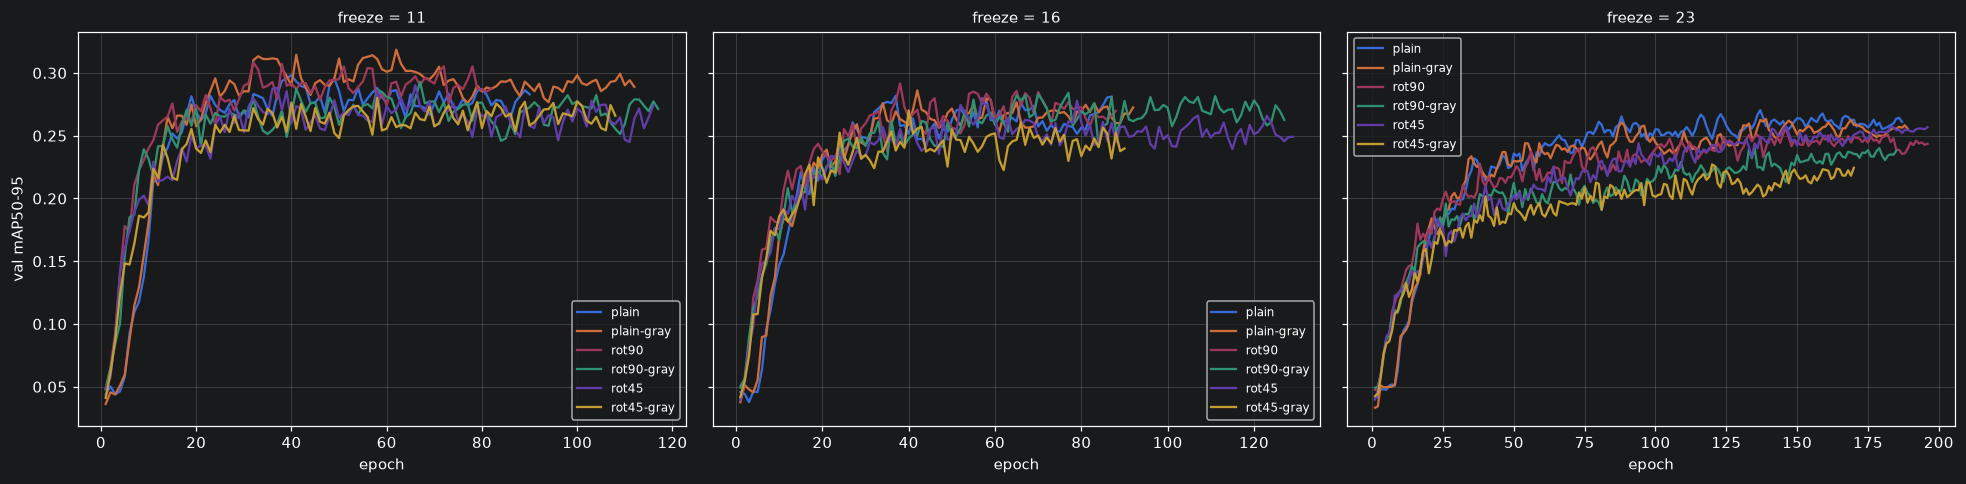

In [12]:
fig, axes = plt.subplots(1, len(freezes), figsize=(6 * len(freezes), 4.5), sharey=True)
for ax, fz in zip(np.atleast_1d(axes), freezes):
    for rec in trained:
        if rec["freeze"] != fz or rec["mosaic"]:
            continue
        df = history(rec)
        ax.plot(df.epoch, df[map_col(df)], label=rec["run"].split("-", 1)[1])
    ax.set_title(f"freeze = {fz}", fontsize=10)
    ax.set_xlabel("epoch")
    ax.legend(fontsize=8)
axes[0].set_ylabel("val mAP50-95")
plt.tight_layout()
plt.show()

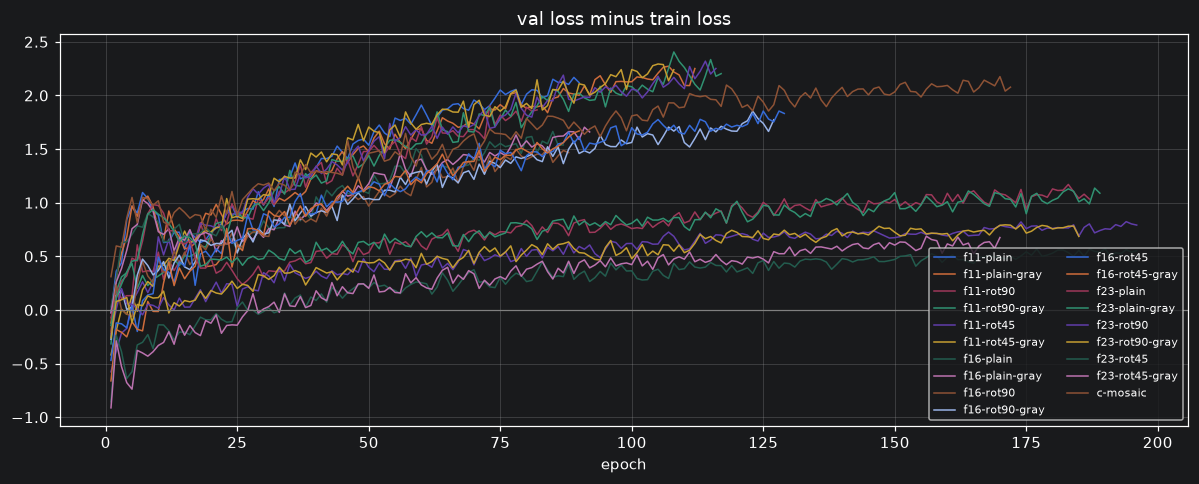

In [13]:
fig, ax = plt.subplots(figsize=(11, 4.5))
for rec in trained:
    df = history(rec)
    train, val = loss_pair(df)
    ax.plot(df.epoch, val - train, label=rec["run"], lw=1)
ax.axhline(0, color="grey", lw=0.8)
ax.set_title("val loss minus train loss")
ax.set_xlabel("epoch")
ax.legend(fontsize=7, ncol=2)
plt.tight_layout()
plt.show()

In [14]:
rows = []
for rec in trained:
    df = history(rec)
    train, val = loss_pair(df)
    pos = int(df[map_col(df)].values.argmax())
    rows.append({"run": rec["run"], "freeze": rec["freeze"], "epochs_run": int(df.epoch.max()),
                 "best_epoch": int(df.epoch.iloc[pos]),
                 "best_val_mAP50_95": round(float(df[map_col(df)].max()), 4),
                 "val_loss_best": round(float(val.min()), 3),
                 "val_loss_end": round(float(val.iloc[-1]), 3)})

curves = pd.DataFrame(rows).set_index("run")
curves["val_rebound"] = (curves.val_loss_end - curves.val_loss_best).round(3)
curves.sort_values("best_val_mAP50_95", ascending=False)

,freeze,epochs_run,best_epoch,best_val_mAP50_95,val_loss_best,val_loss_end,val_rebound
run,,,,,,,
f11-plain-gray,11,112,62,0.3185,4.799,4.917,0.118
f11-rot90,11,82,32,0.3085,4.662,4.859,0.197
c-mosaic,11,172,122,0.3085,4.812,4.834,0.022
f11-plain,11,90,40,0.2983,4.857,5.003,0.146
f11-rot90-gray,11,117,67,0.2929,4.752,4.946,0.194
f16-rot90,16,88,38,0.2917,4.650,4.789,0.139
f11-rot45,11,116,66,0.2902,4.722,4.938,0.216
f16-plain-gray,16,92,42,0.2861,4.827,4.898,0.071
f16-rot90-gray,16,127,77,0.2842,4.697,4.838,0.141


## 6. results

In [15]:
def evaluate(rec, data, split="test"):
    m = YOLO(rec["best"]).val(data=str(data / "data.yaml"), split=split, imgsz=imgsz, batch=batch,
                              device=device, project=str(project), name=f"{rec['run']}-{split}",
                              exist_ok=True, plots=True)
    out = dict(rec)
    out.update({"split": split, "mAP50": round(float(m.box.map50), 4), "mAP50_95": round(float(m.box.map), 4),
                "precision": round(float(m.box.mp), 4), "recall": round(float(m.box.mr), 4),
                "val_dir": str(m.save_dir)})
    return out, m


tested, models = [], {}
for rec in records:
    data = next(v for v in datasets.values() if v.name == rec["dataset"])
    out, m = evaluate(rec, data)
    tested.append(out)
    models[rec["run"]] = m

compare = pd.DataFrame(tested).set_index("run")[
    ["freeze", "dataset", "mosaic", "minutes", "mAP50", "mAP50_95", "precision", "recall"]]
compare.sort_values("mAP50_95", ascending=False)

Ultralytics 8.4.142  Python-3.12.10 torch-2.14.0+cu130 CUDA:0 (NVIDIA GeForce RTX 4080 SUPER, 16376MiB)
YOLO11n summary (fused): 100 layers, 2,583,907 parameters, 0 gradients, 6.4 GFLOPs
val: Fast image access  (ping: 0.10.0 ms, read: 753.31139.9 MB/s, size: 586.1 KB)
val: Scanning E:\PycharmProjects\camel-beauty-assessor\dataset\camel-det-plain\test\labels.cache... 28 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 28/28  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 2/2 1.0it/s 2.0s6.0s
                   all         28        148      0.512      0.609      0.619      0.293
                 Camel         28         38      0.619      0.812      0.826      0.605
          High_withers         11         11      0.471      0.727      0.594      0.185
            Large-head         10         10      0.648      0.555      0.673      0.349
            Large-lips         14         14      0.534      0.821      0.849  

,freeze,dataset,mosaic,minutes,mAP50,mAP50_95,precision,recall
run,,,,,,,,
f11-plain-gray,11,camel-det-gray,0.0,2.6,0.6679,0.3212,0.7396,0.6591
c-mosaic,11,camel-det-plain,1.0,4.3,0.6752,0.3004,0.6317,0.6126
f11-rot90-gray,11,camel-det-aug-gray,0.0,6.6,0.6042,0.2939,0.5113,0.6204
f11-plain,11,camel-det-plain,0.0,2.3,0.6186,0.2930,0.5117,0.6092
f11-rot90,11,camel-det-aug,0.0,4.8,0.5277,0.2723,0.4434,0.5980
f16-plain,16,camel-det-plain,0.0,2.0,0.5287,0.2514,0.5178,0.5397
f16-plain-gray,16,camel-det-gray,0.0,2.1,0.5441,0.2471,0.5178,0.5631
f11-rot45-gray,11,camel-det-rot45-gray,0.0,7.3,0.5518,0.2427,0.5613,0.5750
f16-rot90-gray,16,camel-det-aug-gray,0.0,6.9,0.5105,0.2416,0.5979,0.4213


### 6.1 freeze depth against dataset

In [16]:
grid = compare[compare.mosaic == 0].reset_index()
grid["aug"] = grid.run.str.split("-", n=1).str[1]
pivot = grid.pivot(index="aug", columns="freeze", values="mAP50_95")
pivot["best"] = pivot.max(axis=1)
pivot.sort_values("best", ascending=False)

freeze,11,16,23,best
aug,,,,
plain-gray,0.3212,0.2471,0.2176,0.3212
rot90-gray,0.2939,0.2416,0.1693,0.2939
plain,0.2930,0.2514,0.1979,0.2930
rot90,0.2723,0.2193,0.1797,0.2723
rot45-gray,0.2427,0.2200,0.1800,0.2427
rot45,0.2409,0.2346,0.1807,0.2409


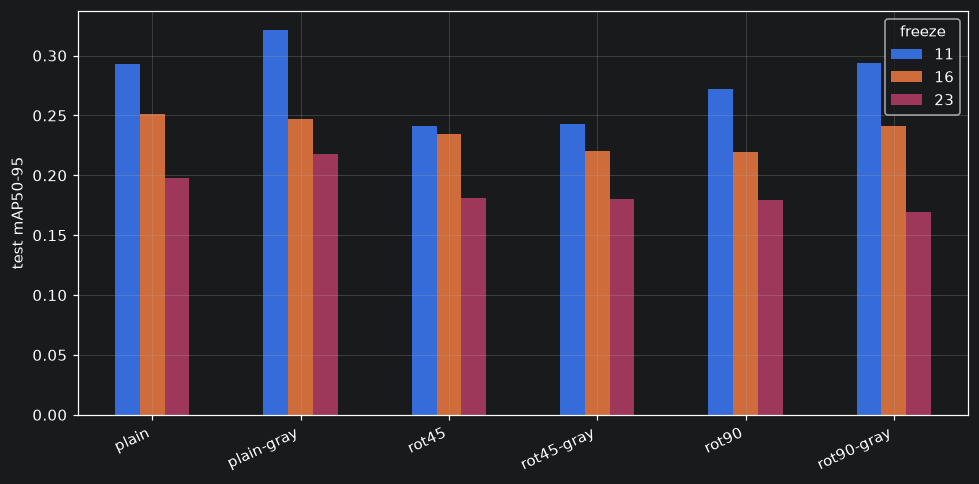

In [17]:
fig, ax = plt.subplots(figsize=(9, 4.5))
pivot.drop(columns="best").plot(kind="bar", ax=ax)
ax.set_ylabel("test mAP50-95")
ax.set_xlabel("")
ax.legend(title="freeze")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

### 6.2 against the fine-tuned runs

In [18]:
prev = pd.read_csv(results / "experiments.csv").drop_duplicates("run", keep="last").set_index("run")
prev = prev[prev.imgsz == imgsz][["dataset", "mAP50", "mAP50_95", "precision", "recall"]]
prev["freeze"] = 0

both = pd.concat([prev, compare[["dataset", "mAP50", "mAP50_95", "precision", "recall", "freeze"]]])
both["vs e0"] = (both.mAP50_95 - prev.loc["e0-nomosaic", "mAP50_95"]).round(4)
both.sort_values("mAP50_95", ascending=False)

,dataset,mAP50,mAP50_95,precision,recall,freeze,vs e0
run,,,,,,,
e0-nomosaic,camel-det-plain,0.6710,0.3233,0.6361,0.6660,0,0.0000
f11-plain-gray,camel-det-gray,0.6679,0.3212,0.7396,0.6591,11,-0.0021
b1-rgb,camel-det,0.6617,0.3206,0.7073,0.6485,0,-0.0027
e1-gray,camel-det-gray,0.6523,0.3091,0.5837,0.7044,0,-0.0142
c-mosaic,camel-det-plain,0.6752,0.3004,0.6317,0.6126,11,-0.0229
b3-aug-gray,camel-det-aug-gray,0.6264,0.2986,0.6857,0.5800,0,-0.0247
f11-rot90-gray,camel-det-aug-gray,0.6042,0.2939,0.5113,0.6204,11,-0.0294
f11-plain,camel-det-plain,0.6186,0.2930,0.5117,0.6092,11,-0.0303
e3-rot45-gray,camel-det-rot45-gray,0.5972,0.2925,0.5969,0.6301,0,-0.0308


### 6.3 per class, best frozen run against the best fine-tuned one

In [19]:
def per_class(m):
    rows = []
    for i, c in enumerate(list(m.box.ap_class_index)):
        p, r, ap50, ap = m.box.class_result(i)
        rows.append({"cls": canon[int(c)], "precision": round(float(p), 3), "recall": round(float(r), 3),
                     "mAP50": round(float(ap50), 3), "mAP50_95": round(float(ap), 3)})
    return pd.DataFrame(rows).set_index("cls").reindex(canon)


winner = compare.mAP50_95.idxmax()
pc = per_class(models[winner])
print(f"best frozen run: {winner}   mAP50-95 {compare.loc[winner, 'mAP50_95']}")
pc

best frozen run: f11-plain-gray   mAP50-95 0.3212


,precision,recall,mAP50,mAP50_95
cls,,,,
Camel,0.836,0.789,0.811,0.644
High_withers,0.728,0.974,0.784,0.300
Large-head,0.740,0.600,0.671,0.351
Large-lips,0.968,0.786,0.933,0.365
Large-nose,0.879,0.692,0.756,0.271
Large_hump,0.444,0.455,0.528,0.170
Long-legs,0.510,0.812,0.548,0.262
Long-neck,0.794,0.739,0.832,0.482
Wide_body,0.756,0.083,0.148,0.046


## 7. mlops artifacts

In [20]:
for rec in tested:
    with mlflow.start_run(run_name=rec["run"] + "-test"):
        mlflow.log_params({k: rec[k] for k in
                           ("freeze", "dataset", "mosaic", "epochs", "imgsz", "batch", "device", "split")})
        mlflow.log_metrics({k: rec[k] for k in ("mAP50", "mAP50_95", "precision", "recall")})
        for art in ("confusion_matrix_normalized.png", "PR_curve.png"):
            f = pathlib.Path(rec["val_dir"]) / art
            if f.exists():
                mlflow.log_artifact(str(f))

out = compare.reset_index()
out.insert(0, "logged_at", pd.Timestamp.now().isoformat(timespec="seconds"))
out.to_csv(results / "freezing.csv", index=False)
pc.to_csv(results / "per_class_frozen.csv")

print(f"{len(out)} rows written to {results / 'freezing.csv'}")
out

19 rows written to E:\PycharmProjects\camel-beauty-assessor\results\freezing.csv


,logged_at,run,freeze,dataset,mosaic,minutes,mAP50,mAP50_95,precision,recall
0,2026-09-08T15:10:40,f11-plain,11,camel-det-plain,0.0,2.3,0.6186,0.2930,0.5117,0.6092
1,2026-09-08T15:10:40,f11-plain-gray,11,camel-det-gray,0.0,2.6,0.6679,0.3212,0.7396,0.6591
2,2026-09-08T15:10:40,f11-rot90,11,camel-det-aug,0.0,4.8,0.5277,0.2723,0.4434,0.5980
3,2026-09-08T15:10:40,f11-rot90-gray,11,camel-det-aug-gray,0.0,6.6,0.6042,0.2939,0.5113,0.6204
4,2026-09-08T15:10:40,f11-rot45,11,camel-det-rot45,0.0,7.9,0.5449,0.2409,0.6069,0.5023
5,2026-09-08T15:10:40,f11-rot45-gray,11,camel-det-rot45-gray,0.0,7.3,0.5518,0.2427,0.5613,0.5750
6,2026-09-08T15:10:40,f16-plain,16,camel-det-plain,0.0,2.0,0.5287,0.2514,0.5178,0.5397
7,2026-09-08T15:10:40,f16-plain-gray,16,camel-det-gray,0.0,2.1,0.5441,0.2471,0.5178,0.5631
8,2026-09-08T15:10:40,f16-rot90,16,camel-det-aug,0.0,5.1,0.4763,0.2193,0.5831,0.4987
9,2026-09-08T15:10:40,f16-rot90-gray,16,camel-det-aug-gray,0.0,6.9,0.5105,0.2416,0.5979,0.4213
